Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load continuous wrist flexion data from Delsys Galileo sensor

In [6]:
df = pd.read_csv("maize_isometric_male.csv", header=0)
df.columns = ["ch_1_time", "ch_1_voltage", 
              "ch_2_time", "ch_2_voltage", 
              "ch_3_time", "ch_3_voltage", 
              "ch_4_time", "ch_4_voltage",
              "ch_5_time", "ch_5_voltage",
              "ch_6_time", "ch_6_voltage",
              "ch_7_time", "ch_7_voltage",
              "ch_8_time", "ch_8_voltage",
              "ch_9_time", "ch_9_voltage",
              "ch_10_time", "ch_10_voltage",
              "ch_11_time", "ch_11_voltage",
              "ch_12_time", "ch_12_voltage",
              "ch_13_time", "ch_13_voltage",
              "ch_14_time", "ch_14_voltage",
              "ch_15_time", "ch_15_voltage",
              "ch_16_time", "ch_16_voltage"]
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()

C:\Users\xvanq\AppData\Local\Temp\ipykernel_11152\802161533.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("maize_isometric_male.csv", header=0)


Define function to compute MDF over time for multiple EMG channels

In [7]:
# Inputs: Array of time (s) values, array of voltage (mV) values, window size (s), step size (s)
# Outputs: Array of time values (s), array of MDF values (Hz)

def compute_mdf(channel_time, channel_voltage, window_time, step_time):

    # Define axes
    time = channel_time.to_numpy()
    voltage = channel_voltage.to_numpy()

    # Subtract mean to remove DC offset (spike at 0 Hz)
    voltage = voltage - np.mean(voltage)

    # Sampling information
    dt = np.mean(np.diff(time))             # Interval in seconds (mean time between samples)
    Fs = 1 / dt                             # Frequency in Hz
    N = len(voltage)                        # Number of samples
    window_size = int(window_time * Fs)     # Number of samples in each window
    step_size = int(step_time * Fs)         # Number of samples to step for each

    window_times = []
    mdf_values = []

    # Loop through windows
    for start in range(0, N - window_size + 1, step_size):
        end = start + window_size
        
        # Time and voltage values for current window
        segment_time = time[start:end]
        segment_voltage = voltage[start:end]

        # FFT
        fft_amplitude = np.fft.fft(segment_voltage)
        fft_freq = np.fft.fftfreq(window_size, d=dt)

        # Keep only positive frequencies
        freqs = fft_freq[fft_freq >= 0]

        # Calculate signal power values
        power = np.abs(fft_amplitude[fft_freq >= 0]) ** 2   # Power is the square of the amplitude
        cumulative_power = np.cumsum(power)                 # Cumulative sum of power
        total_power = np.sum(power)                         # Total power in the signal

        # Calculate MDF as the first value where cumulative power >= 50% of total power
        mdf = freqs[np.where(cumulative_power >= 0.5 * total_power)[0][0]]

        # Use the midpoint of the window as the corresponding time for each MDF value
        window_times.append(segment_time[len(segment_time) // 2])
        mdf_values.append(mdf)

    return np.array(window_times), np.array(mdf_values)


Plot MDF outputs

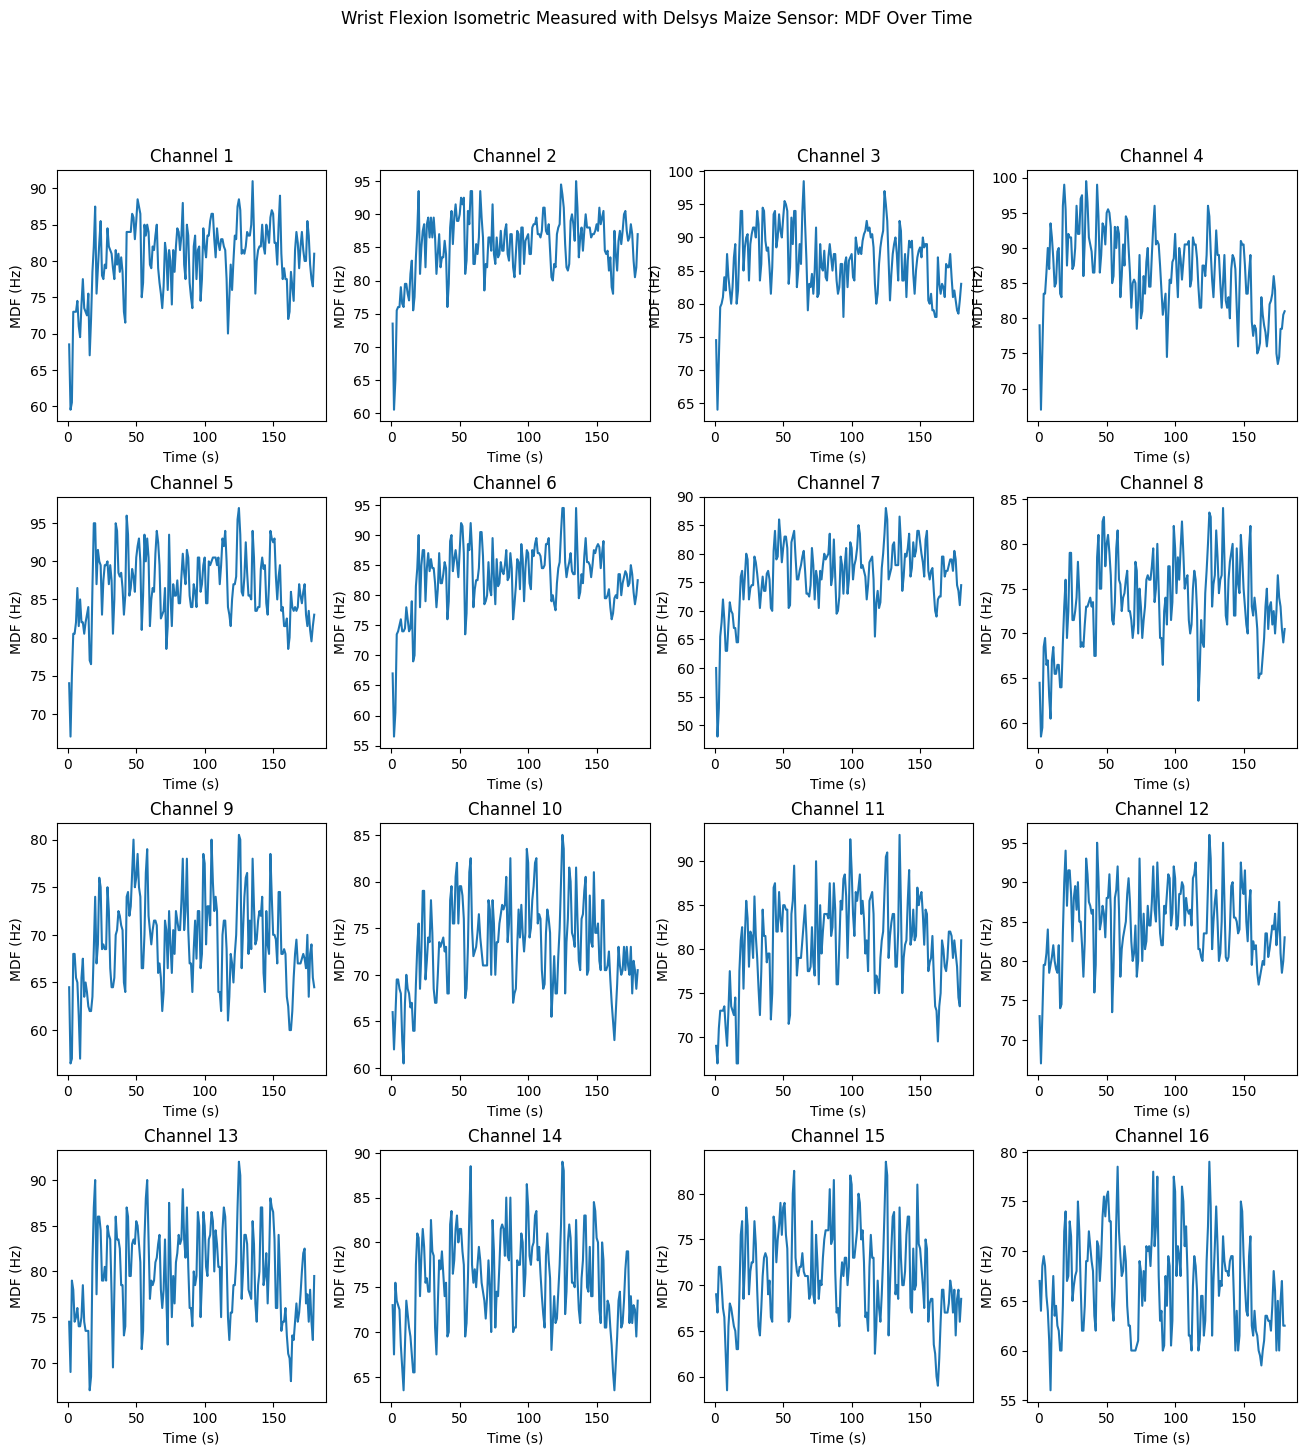

In [9]:
fig, ((ax1, ax2, ax3, ax4),
      (ax5, ax6, ax7, ax8),
      (ax9, ax10, ax11, ax12),
      (ax13, ax14, ax15, ax16)) = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Wrist Flexion Isometric Measured with Delsys Maize Sensor: MDF Over Time")
fig.subplots_adjust(hspace=0.3)

time, mdf = compute_mdf(df["ch_1_time"], df["ch_1_voltage"], window_time=2, step_time=1)
ax1.plot(time, mdf)
ax1.set_title("Channel 1")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("MDF (Hz)")

time_2, mdf_2 = compute_mdf(df["ch_2_time"], df["ch_2_voltage"], window_time=2, step_time=1)
ax2.plot(time_2, mdf_2)
ax2.set_title("Channel 2")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("MDF (Hz)")

time_3, mdf_3 = compute_mdf(df["ch_3_time"], df["ch_3_voltage"], window_time=2, step_time=1)
ax3.plot(time_3, mdf_3)
ax3.set_title("Channel 3")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("MDF (Hz)")

time_4, mdf_4 = compute_mdf(df["ch_4_time"], df["ch_4_voltage"], window_time=2, step_time=1)
ax4.plot(time_4, mdf_4)
ax4.set_title("Channel 4")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("MDF (Hz)")

time_5, mdf_5 = compute_mdf(df["ch_5_time"], df["ch_5_voltage"], window_time=2, step_time=1)
ax5.plot(time_5, mdf_5)
ax5.set_title("Channel 5")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel("MDF (Hz)")

time_6, mdf_6 = compute_mdf(df["ch_6_time"], df["ch_6_voltage"], window_time=2, step_time=1)
ax6.plot(time_6, mdf_6)
ax6.set_title("Channel 6")
ax6.set_xlabel("Time (s)")
ax6.set_ylabel("MDF (Hz)")

time_7, mdf_7 = compute_mdf(df["ch_7_time"], df["ch_7_voltage"], window_time=2, step_time=1)
ax7.plot(time_7, mdf_7)
ax7.set_title("Channel 7")
ax7.set_xlabel("Time (s)")
ax7.set_ylabel("MDF (Hz)")

time_8, mdf_8 = compute_mdf(df["ch_8_time"], df["ch_8_voltage"], window_time=2, step_time=1)
ax8.plot(time_8, mdf_8)
ax8.set_title("Channel 8")
ax8.set_xlabel("Time (s)")
ax8.set_ylabel("MDF (Hz)")

time_9, mdf_9 = compute_mdf(df["ch_9_time"], df["ch_9_voltage"], window_time=2, step_time=1)
ax9.plot(time_9, mdf_9)
ax9.set_title("Channel 9")
ax9.set_xlabel("Time (s)")
ax9.set_ylabel("MDF (Hz)")

time_10, mdf_10 = compute_mdf(df["ch_10_time"], df["ch_10_voltage"], window_time=2, step_time=1)
ax10.plot(time_10, mdf_10)
ax10.set_title("Channel 10")
ax10.set_xlabel("Time (s)")
ax10.set_ylabel("MDF (Hz)")

time_11, mdf_11 = compute_mdf(df["ch_11_time"], df["ch_11_voltage"], window_time=2, step_time=1)
ax11.plot(time_11, mdf_11)
ax11.set_title("Channel 11")
ax11.set_xlabel("Time (s)")
ax11.set_ylabel("MDF (Hz)")

time_12, mdf_12 = compute_mdf(df["ch_12_time"], df["ch_12_voltage"], window_time=2, step_time=1)
ax12.plot(time_12, mdf_12)
ax12.set_title("Channel 12")
ax12.set_xlabel("Time (s)")
ax12.set_ylabel("MDF (Hz)")

time_13, mdf_13 = compute_mdf(df["ch_13_time"], df["ch_13_voltage"], window_time=2, step_time=1)
ax13.plot(time_13, mdf_13)
ax13.set_title("Channel 13")
ax13.set_xlabel("Time (s)")
ax13.set_ylabel("MDF (Hz)")

time_14, mdf_14 = compute_mdf(df["ch_14_time"], df["ch_14_voltage"], window_time=2, step_time=1)
ax14.plot(time_14, mdf_14)
ax14.set_title("Channel 14")
ax14.set_xlabel("Time (s)")
ax14.set_ylabel("MDF (Hz)")

time_15, mdf_15 = compute_mdf(df["ch_15_time"], df["ch_15_voltage"], window_time=2, step_time=1)
ax15.plot(time_15, mdf_15)
ax15.set_title("Channel 15")
ax15.set_xlabel("Time (s)")
ax15.set_ylabel("MDF (Hz)")

time_16, mdf_16 = compute_mdf(df["ch_16_time"], df["ch_16_voltage"], window_time=2, step_time=1)
ax16.plot(time_16, mdf_16)
ax16.set_title("Channel 16")
ax16.set_xlabel("Time (s)")
ax16.set_ylabel("MDF (Hz)")

plt.show()